# Week 1

Andrew Chung (hc893), 11/13/2024

## Explore AF Metrics

- **pDockQ**
    - DockQ = tool for evaluating protein-protein docking models generated by AF.
    - With a predicted protein complex structure as input, it calculates scores based on features related to the interaction surface (e.g. amount of buried surface area, # of residue contacts)
    - The pDockQ score can interpret the quality of docking (higher scores), distinguish plausible from implausible PPIs
- **pTM**
    - Predicted template modelling
    - Integrated measure of how well AFM predicts the overall structure of the complex.
    - It is the predicted TM score for a superposition betwen predicted structure and hypothetical true structure. 
    - $\text{pTM} > 0.5$ suggests that the predicted fold for complex may be similar to true structure; likely wrong if $\text{pTM} < 0.5$.
- **ipTM**
    - Interface predicted template modelling
    - Measures the accuracy of the predicted relative positions of the subunits forming the protein-protein complex.
    - $\text{ipTM} > 0.8$ represents confident high-quality predictions, while $\text{iPTM} < 0.6$ suggests a likely failed prediction.
    - $0.6 \leq \text{ipTM} \leq 0.8$ suggests a grey zone, predictions could be correct or wrong.
    - Generally, ipTM more useful than pTM due to high interdependence between predicted relative positions of subunits and quality of whole-complex prediction.
- **ranking_score**
    - TODO
- **pLDDT**
    - Predicted Local Distance Difference Test
    - Measure of confidence in local structure (per-residue), estimating how well the prediction agrees with experimental structure. Scaled from 0 to 100
    - $\text{pLDDT} > 90$ = both backbone and side chains predicted with high accuracy
    - $\text{pLDDT} > 70$ = correct backbone prediction, some misplacement of side chains
    - Can vary significantly along a protein chain, giving an indication of which parts of predicted structure are reliable and which are unlikely to be.
- **pAE**
    - Predicted Aligned Error
    - Estimation of the expected positional error for each residue in predicted protein structure if it were aligned to a corresponding residue in true protein structure.
    - Low pAE = high confidence that two regions of the protein are in the right places relative to one another, high pAE = uncertainty in alignment.
    - Represented on a 2D space, $(x,y)$, symbolizing the predicted position error at residue $x$ if the predicted, true structures were aligned on residue $y$.
- **LIS**
    - Local Interaction Score
    - Modification of pAE, featuring enhanced sensitivity in detecting PPI (esp. flexible, small interfaces)
    - Select region(s) with lowest pAE values - local interaction areas (LIAs)
    - Inverse mapping of pAE values within the LIA to derive a value between 0 and 1, where higher number = stronger inferred interaction
    - LIS is calculated as the average of inverted pAE values across interfaces of interacting protein pair.

## Task 2: Plotting

In [36]:
# import AF3 scores csv
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import pearsonr

af3 = pd.read_csv("AF3_scores.csv")
af3["len"] = af3.apply(lambda row: len(row["sequence_A"]) + len(row["sequence_B"]), axis = 1)
af3.head()

,Protein_A,Protein_B,nonstr_label,str_label,pLDDT,pAE,pDockQ,pDockQ2,LIS,ipTM,pTM,ranking_score,label,sequence_A,sequence_B,len
0,p81534,q15125,-1,-1,73.472,14.163,0.060195,0.019349,0.508,0.15,0.65,0.32,0,MRIHYLLFALLFLFLVPVPGHGGIINTLQKYYCRVRGGRCAVLSCL...,MTTNAGPLHPYWPQHLRLDNFVPNDRPTWHILAGLFSVTGVLVVTT...,297
1,p50213,p51553,1,1,86.357,9.471,0.703746,0.071464,0.572,0.87,0.85,0.91,1,MAGPAWISKVSRLLGAFHNPKQVTRGFTGGVQTVTLIPGDGIGPEI...,MALKVATVAGSAAKAVLGPALLCRPWEVLGAHEVPSRNIFSEQTIP...,759
2,p78383,q13113,-1,-1,70.243,16.194,0.190604,0.014878,0.556,0.26,0.65,0.47,0,MASSSSLVPDRLRLPLCFLGVFVCYFYYGILQEKITRGKYGEGAKQ...,MSALSLLILGLLTAVPPASCQQGLGNLQPWMQGLIAVAVFLVLVAI...,436
3,p50225,q8ixf9,0,-1,65.510,20.306,0.029251,0.011056,0.000,0.15,0.49,0.26,0,MELIQDTSRPPLEYVKGVPLIKYFAEALGPLQSFQARPDDLLISTY...,MAGLNVSLSFFFATFALCEAARRASKALLPVGAYEVFAREAMRTLV...,590
4,p82650,p82914,-1,0,72.267,21.250,0.023665,0.011199,0.372,0.22,0.50,0.45,0,MAPLGTTVLLWSLLRSSPGVERVCFRARIQPWHGGLLQPLPCSFEM...,MLRVAWRTLSLIRTRAVTQVLVPGLPGGGSAKFPFNQWGLQPRSLL...,617


In [10]:
# filter out -1 pairs
af3_nonstr = af3[af3["nonstr_label"] > -1]
af3_str = af3[af3["str_label"] > -1]

### `pLDDT` vs. length (example)

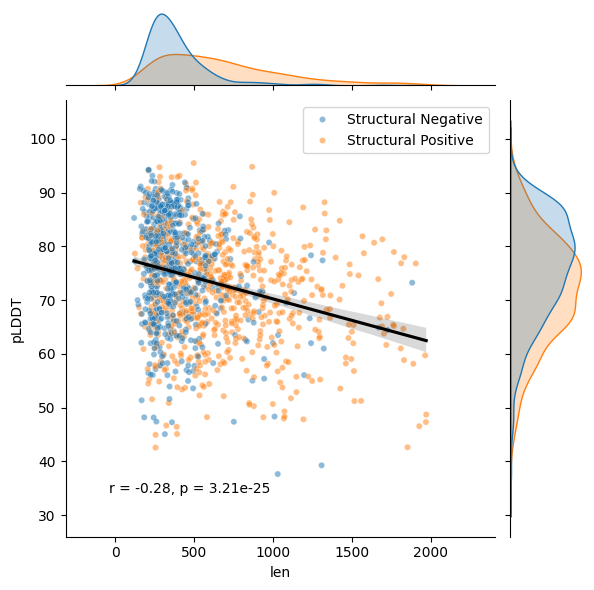

In [37]:
x = sns.jointplot(data = af3_str, x = "len", y = "pLDDT", hue = "str_label", alpha = 0.5, s = 20)

# compute regression
r, p = pearsonr(af3_str["len"], af3_str["pLDDT"])
x.ax_joint.text(0.1, 0.1, f"r = {r:.2f}, p = {p:.2e}", transform=x.ax_joint.transAxes)
sns.regplot(data = af3_str, x = "len", y = "pLDDT", ax = x.ax_joint, scatter = False, color = "black")

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["Structural Negative", "Structural Positive"]
plt.legend(handles, new_labels)

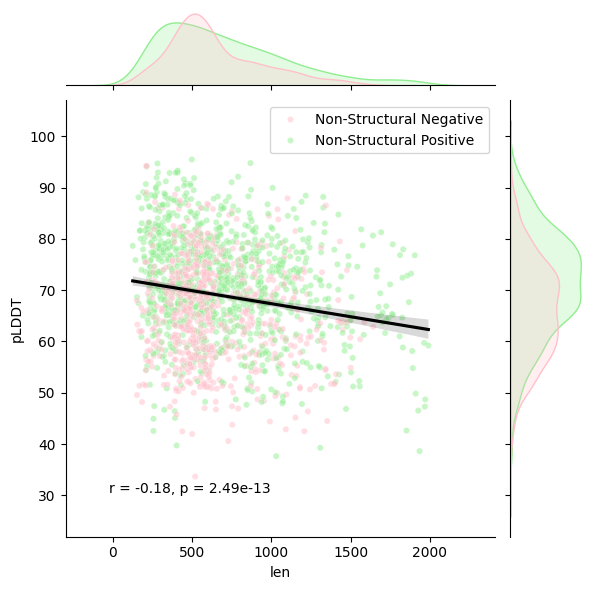

In [39]:
x = sns.jointplot(data = af3_nonstr, x = "len", y = "pLDDT", hue = "nonstr_label", 
alpha = 0.5, s = 20, palette = sns.color_palette(["pink", "lightgreen"]))

# compute regression
r, p = pearsonr(af3_nonstr["len"], af3_nonstr["pLDDT"])
x.ax_joint.text(0.1, 0.1, f"r = {r:.2f}, p = {p:.2e}", transform=x.ax_joint.transAxes)
sns.regplot(data = af3_nonstr, x = "len", y = "pLDDT", ax = x.ax_joint, scatter = False, color = "black")

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["Non-Structural Negative", "Non-Structural Positive"]
plt.legend(handles, new_labels)

### `ipTM` vs. length

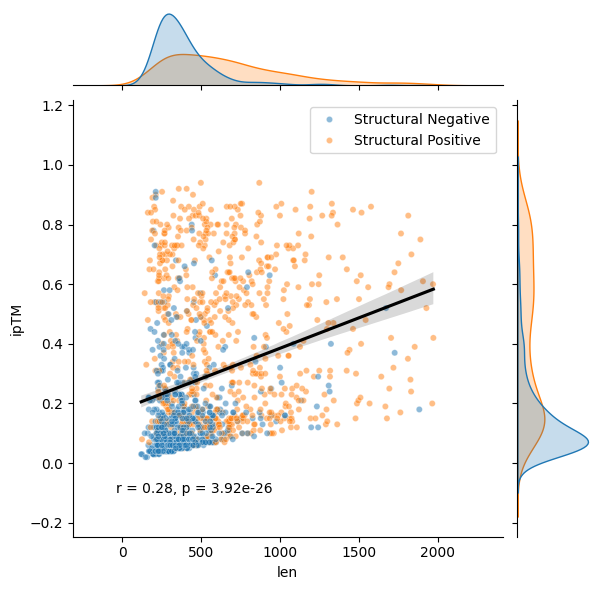

In [40]:
# structural + vs. -
x = sns.jointplot(data = af3_str, x = "len", y = "ipTM", hue = "str_label", alpha = 0.5, s = 20)

# compute regression
r, p = pearsonr(af3_str["len"], af3_str["ipTM"])
x.ax_joint.text(0.1, 0.1, f"r = {r:.2f}, p = {p:.2e}", transform=x.ax_joint.transAxes)
sns.regplot(data = af3_str, x = "len", y = "ipTM", ax = x.ax_joint, scatter = False, color = "black")

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["Structural Negative", "Structural Positive"]
plt.legend(handles, new_labels)

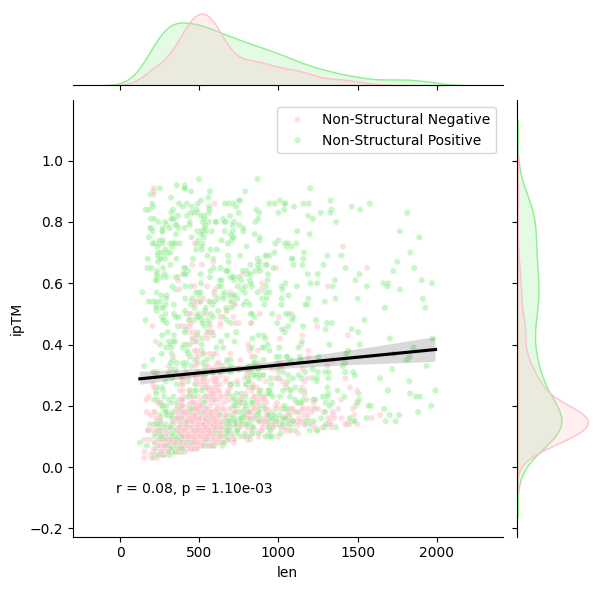

In [44]:
# nonstructural + vs. -
x = sns.jointplot(data = af3_nonstr, x = "len", y = "ipTM", hue = "nonstr_label", 
  alpha = 0.5, s = 20, palette = sns.color_palette(["pink", "lightgreen"]))

# compute regression
r, p = pearsonr(af3_nonstr["len"], af3_nonstr["ipTM"])
x.ax_joint.text(0.1, 0.1, f"r = {r:.2f}, p = {p:.2e}", transform=x.ax_joint.transAxes)
sns.regplot(data = af3_nonstr, x = "len", y = "ipTM", ax = x.ax_joint, scatter = False, color = "black")

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["Non-Structural Negative", "Non-Structural Positive"]
plt.legend(handles, new_labels)

### `ranking_score` vs. length

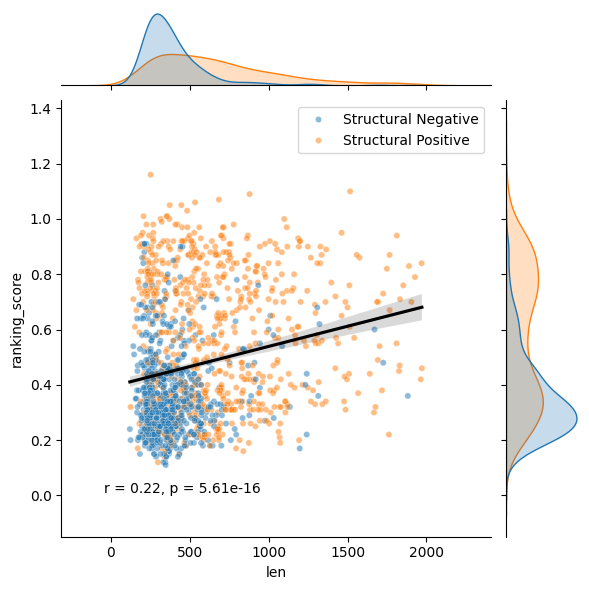

In [47]:
# structural + vs. -
x = sns.jointplot(data = af3_str, x = "len", y = "ranking_score", hue = "str_label", alpha = 0.5, s = 20)

# compute regression
r, p = pearsonr(af3_str["len"], af3_str["ranking_score"])
x.ax_joint.text(0.1, 0.1, f"r = {r:.2f}, p = {p:.2e}", transform=x.ax_joint.transAxes)
sns.regplot(data = af3_str, x = "len", y = "ranking_score", ax = x.ax_joint, scatter = False, color = "black")

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["Structural Negative", "Structural Positive"]
plt.legend(handles, new_labels)

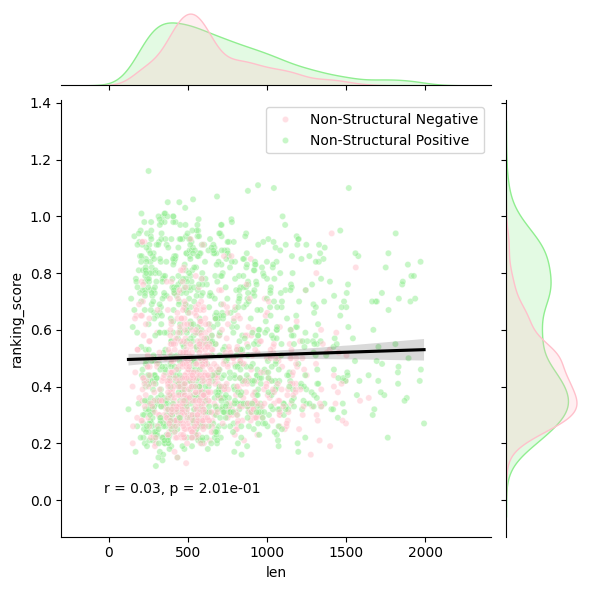

In [48]:
# nonstructural + vs. -
x = sns.jointplot(data = af3_nonstr, x = "len", y = "ranking_score", hue = "nonstr_label", 
  alpha = 0.5, s = 20, palette = sns.color_palette(["pink", "lightgreen"]))

  # compute regression
r, p = pearsonr(af3_nonstr["len"], af3_nonstr["ranking_score"])
x.ax_joint.text(0.1, 0.1, f"r = {r:.2f}, p = {p:.2e}", transform=x.ax_joint.transAxes)
sns.regplot(data = af3_nonstr, x = "len", y = "ranking_score", ax = x.ax_joint, scatter = False, color = "black")

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["Non-Structural Negative", "Non-Structural Positive"]
plt.legend(handles, new_labels)